# Analisis Sentimen Wondr by BNI 2 Algorithm (LSTM & GRU)

In [1]:
!pip install google-play-scraper Sastrawi tensorflow scikit-learn matplotlib pandas numpy nltk emoji wordcloud

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 12.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import nltk,re,time
import emoji
from google_play_scraper import reviews, Sort
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [3]:
# Scraping 5000 review
APP_ID='id.bni.wondr'
TOTAL_REVIEWS=5000
BATCH_SIZE=200
all_reviews=[]
token=None
while len(all_reviews)<TOTAL_REVIEWS:
    batch,token=reviews(APP_ID,lang='id',country='id',sort=Sort.NEWEST,count=BATCH_SIZE,continuation_token=token)
    all_reviews.extend(batch)
    if token is None:
        break
    time.sleep(1)
df=pd.DataFrame(all_reviews[:TOTAL_REVIEWS])
df.to_csv('wondrbyBNI.csv',index=False,encoding='utf-8-sig')
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,2a5137e2-fb52-4bc8-aaa1-c22edc2f5e83,heru jp,https://play-lh.googleusercontent.com/a-/ALV-U...,masok,5,0,1.5.1,2026-07-08 03:49:20,None,NaT,1.5.1
1,a1e0eabc-f6e2-4cfe-b01a-64624d8fd920,Ozil Malatepo123,https://play-lh.googleusercontent.com/a/ACg8oc...,Kren,5,0,1.5.1,2026-07-08 03:45:54,None,NaT,1.5.1
2,69bded69-3726-4edf-a1a3-28a5857ffbd1,Edi yulianto,https://play-lh.googleusercontent.com/a/ACg8oc...,Parah mau buka aplikasi susah banget sudah 5 k...,1,0,1.5.1,2026-07-08 03:35:35,"Hai Kak Edi, maaf utk kendalanya. Untuk verifi...",2026-07-08 07:04:41,1.5.1
3,5314b8d4-c7fd-495f-b3dc-90f908c363fa,Dendi Fauzi Rahman,https://play-lh.googleusercontent.com/a/ACg8oc...,memudah transaksi tapi pas awal bulan suka lag 🥲,5,0,1.5.1,2026-07-08 03:19:30,None,NaT,1.5.1
4,0924ed41-f011-41dc-b628-7db0cb3f4861,okta 95,https://play-lh.googleusercontent.com/a/ACg8oc...,ini aplikasi jos jis banget,5,0,0.1.4,2026-07-08 03:01:08,None,NaT,0.1.4


## Lanjutkan dengan EDA, preprocessing, pelabelan, LSTM, dan evaluasi.

TAHAP 2 : EXPLORATORY DATA ANALYSIS

Ukuran Dataset
------------------------------------------------------------
Jumlah Baris : 5000
Jumlah Kolom : 11

Informasi Dataset
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              5000 non-null   object
 1   userName              5000 non-null   object
 2   userImage             5000 non-null   object
 3   content               5000 non-null   object
 4   score                 5000 non-null   int64 
 5   thumbsUpCount         5000 non-null   int64 
 6   reviewCreatedVersion  4561 non-null   object
 7   at                    5000 non-null   object
 8   replyContent          1408 non-null   object
 9   repliedAt             1408 non-null   object
 10  appVersion            4561 non-null   object
dtypes: int6

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,2a5137e2-fb52-4bc8-aaa1-c22edc2f5e83,heru jp,https://play-lh.googleusercontent.com/a-/ALV-U...,masok,5,0,1.5.1,2026-07-08 03:49:20,NaN,NaN,1.5.1
1,a1e0eabc-f6e2-4cfe-b01a-64624d8fd920,Ozil Malatepo123,https://play-lh.googleusercontent.com/a/ACg8oc...,Kren,5,0,1.5.1,2026-07-08 03:45:54,NaN,NaN,1.5.1
2,69bded69-3726-4edf-a1a3-28a5857ffbd1,Edi yulianto,https://play-lh.googleusercontent.com/a/ACg8oc...,Parah mau buka aplikasi susah banget sudah 5 k...,1,0,1.5.1,2026-07-08 03:35:35,"Hai Kak Edi, maaf utk kendalanya. Untuk verifi...",2026-07-08 07:04:41,1.5.1
3,5314b8d4-c7fd-495f-b3dc-90f908c363fa,Dendi Fauzi Rahman,https://play-lh.googleusercontent.com/a/ACg8oc...,memudah transaksi tapi pas awal bulan suka lag 🥲,5,0,1.5.1,2026-07-08 03:19:30,NaN,NaN,1.5.1
4,0924ed41-f011-41dc-b628-7db0cb3f4861,okta 95,https://play-lh.googleusercontent.com/a/ACg8oc...,ini aplikasi jos jis banget,5,0,0.1.4,2026-07-08 03:01:08,NaN,NaN,0.1.4



5 Data Terakhir


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
4995,6bb0fa8b-30bb-47e7-a884-3cc64fc65aca,Yulius Setra,https://play-lh.googleusercontent.com/a-/ALV-U...,mantap bni,5,0,1.5.0,2026-05-31 08:22:48,NaN,NaN,1.5.0
4996,679eee06-56c3-41b5-a042-1d1de57f4804,Mayor uus Uus,https://play-lh.googleusercontent.com/a/ACg8oc...,mntap,5,0,1.5.0,2026-05-31 08:09:24,NaN,NaN,1.5.0
4997,8de24fb6-b08b-40cc-9bbe-29ee124c6737,Windi Anisa,https://play-lh.googleusercontent.com/a-/ALV-U...,baik,4,0,1.5.0,2026-05-31 08:08:50,"Hai Kak Windi Anisa, makasih ya udah pakai won...",2026-05-31 09:02:19,1.5.0
4998,2860653c-027f-4307-96d7-f786f59801c7,Alvy pratiwi,https://play-lh.googleusercontent.com/a/ACg8oc...,"bagus, mempermudah",5,0,1.5.0,2026-05-31 08:01:29,NaN,NaN,1.5.0
4999,86709c96-1860-48ac-bfd8-730f5e6c69f8,Nano 01,https://play-lh.googleusercontent.com/a/ACg8oc...,oke aplikasi ini baik..membantu sekali bagi saya.,5,0,1.5.0,2026-05-31 07:43:50,NaN,NaN,1.5.0



Missing Value


,Jumlah Missing
reviewId,0
userName,0
userImage,0
content,0
score,0
thumbsUpCount,0
reviewCreatedVersion,439
at,0
replyContent,3592
repliedAt,3592



Data Duplikat
Duplikat Seluruh Baris : 0
Duplikat Isi Review    : 2014


,Jumlah Review
score,
1,721
2,153
3,198
4,328
5,3600


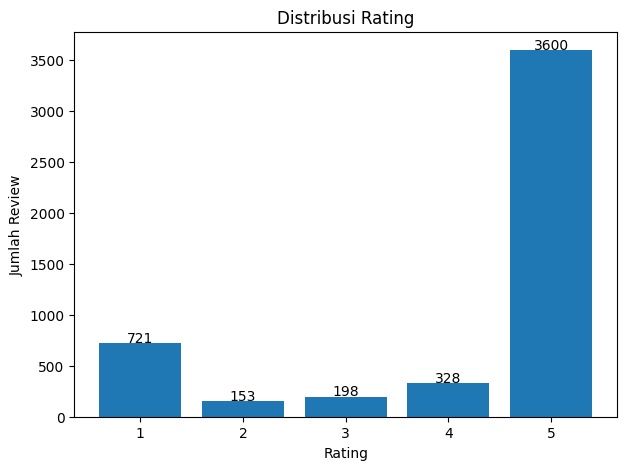

,jumlah_kata
count,5000.000000
mean,6.576800
std,10.655159
min,1.000000
25%,1.000000
50%,2.000000
75%,7.000000
max,92.000000


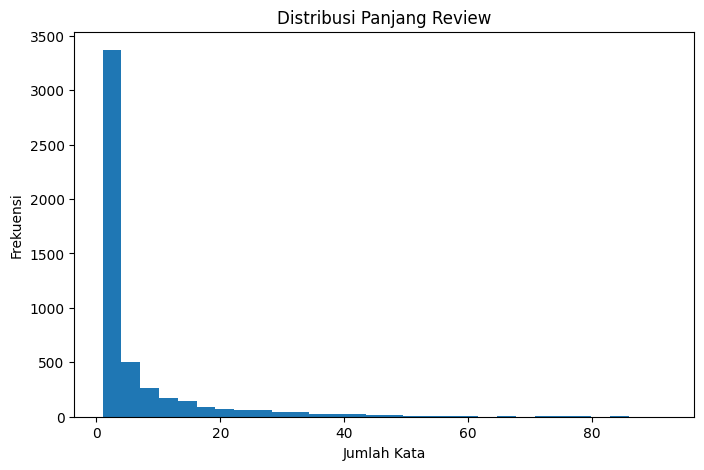

,Jumlah
content,
mantap,275
bagus,242
ok,185
baik,165
good,138
sangat bagus,102
sangat membantu,90
sangat baik,86
oke,51



EDA selesai.


In [4]:
print("="*60)
print("TAHAP 2 : EXPLORATORY DATA ANALYSIS")
print("="*60)

# Load dataset hasil scraping
df = pd.read_csv("wondrbyBNI.csv")

print("\nUkuran Dataset")
print("-"*60)
print(f"Jumlah Baris : {df.shape[0]}")
print(f"Jumlah Kolom : {df.shape[1]}")

print("\nInformasi Dataset")
print("-"*60)
df.info()

print("\n5 Data Pertama")
display(df.head())

print("\n5 Data Terakhir")
display(df.tail())

# ==================================================
# Missing Value
# ==================================================

print("\nMissing Value")
missing = df.isnull().sum()

display(missing.to_frame("Jumlah Missing"))

# ==================================================
# Data Duplikat
# ==================================================

print("\nData Duplikat")

duplikat_baris = df.duplicated().sum()
duplikat_review = df["content"].duplicated().sum()

print("Duplikat Seluruh Baris :", duplikat_baris)
print("Duplikat Isi Review    :", duplikat_review)

# ==================================================
# Hapus Missing
# ==================================================

df.dropna(subset=["content"], inplace=True)
df.reset_index(drop=True, inplace=True)

# ==================================================
# Distribusi Rating
# ==================================================

rating = df["score"].value_counts().sort_index()

display(rating.to_frame("Jumlah Review"))

plt.figure(figsize=(7,5))
plt.bar(rating.index.astype(str), rating.values)

plt.title("Distribusi Rating")
plt.xlabel("Rating")
plt.ylabel("Jumlah Review")

for i,v in enumerate(rating.values):
    plt.text(i,v+10,str(v),ha="center")

plt.show()

# ==================================================
# Statistik Panjang Review
# ==================================================

df["jumlah_kata"] = df["content"].astype(str).apply(
    lambda x: len(x.split())
)

display(df["jumlah_kata"].describe())

plt.figure(figsize=(8,5))
plt.hist(df["jumlah_kata"],bins=30)

plt.title("Distribusi Panjang Review")
plt.xlabel("Jumlah Kata")
plt.ylabel("Frekuensi")

plt.show()

# ==================================================
# Review yang Paling Sering Muncul
# ==================================================

display(
    df["content"]
    .value_counts()
    .head(10)
    .to_frame("Jumlah")
)

df.to_csv(
    "wondrbyBNI_clean.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nEDA selesai.")

TAHAP 3 : TEXT PREPROCESSING

Hasil Preprocessing


,content,stemming
0,masok,masok
1,Kren,kren
2,Parah mau buka aplikasi susah banget sudah 5 k...,parah buka aplikasi susah banget kali buka tam...
3,memudah transaksi tapi pas awal bulan suka lag 🥲,mudah transaksi pas suka lag
4,ini aplikasi jos jis banget,aplikasi jos jis banget



Statistik Panjang Review


,jumlah_kata
count,5000.000000
mean,3.977400
std,6.198175
min,0.000000
25%,1.000000
50%,2.000000
75%,4.000000
max,57.000000


,Kata,Frekuensi
0,bagus,682
1,aplikasi,546
2,mudah,449
3,transaksi,421
4,mantap,421
5,bni,410
6,bantu,360
7,masuk,262
8,ok,262
9,cepat,237


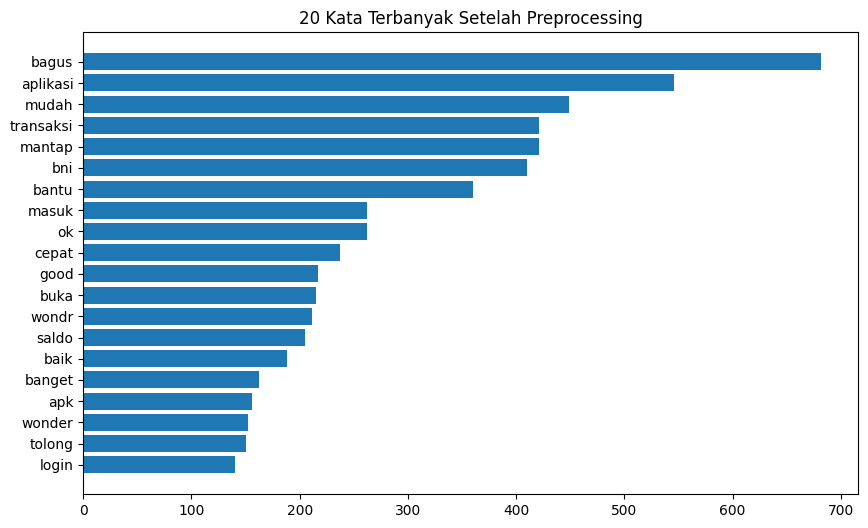

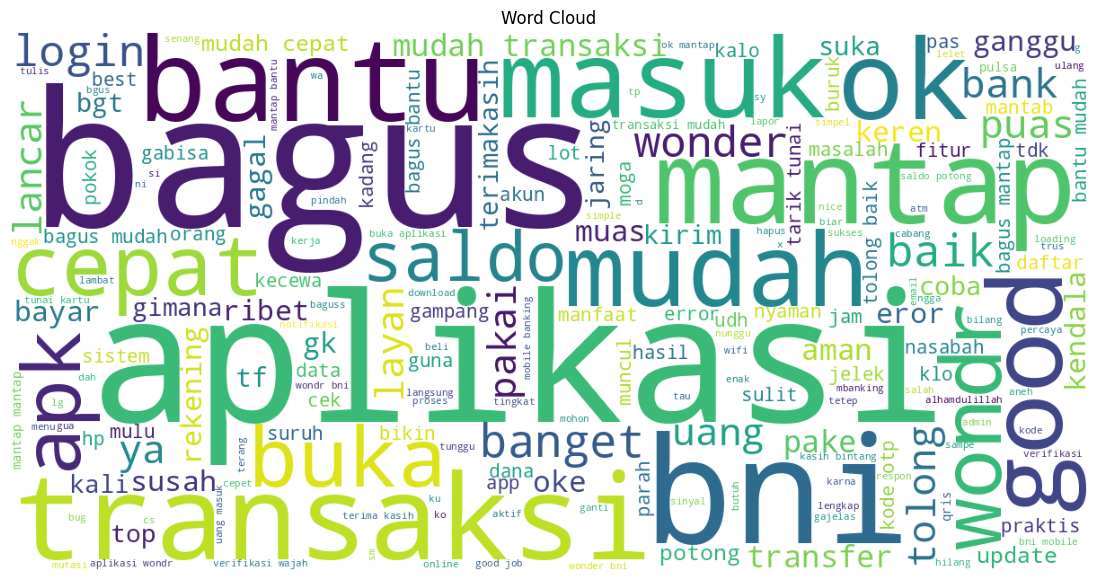


Preprocessing selesai.
Dataset disimpan sebagai wondrbyBNI_preprocessing.csv


In [5]:
import re
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import emoji
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

df = pd.read_csv('wondrbyBNI_clean.csv')

# ==========================================================
# TAHAP 3 : TEXT PREPROCESSING
# ==========================================================

print("="*60)
print("TAHAP 3 : TEXT PREPROCESSING")
print("="*60)

# ==========================================================
# STEMMER DAN STOPWORDS
# ==========================================================

factory = StemmerFactory()
stemmer = factory.create_stemmer()

stop_words = set(stopwords.words("indonesian"))

custom_stopwords = {
    "yg","nya","aja","ga","gak","nih",
    "dong","kok","sih","udah","br"
}

stop_words.update(custom_stopwords)

# ==========================================================
# CASE FOLDING
# ==========================================================

df["case_folding"] = df["content"].astype(str).str.lower()

# ==========================================================
# CLEANING
# ==========================================================

def cleaning(text):

    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#\w+", " ", text)

    text = emoji.replace_emoji(text, replace="")

    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text

df["cleaning"] = df["case_folding"].apply(cleaning)

# ==========================================================
# TOKENIZING
# ==========================================================

df["tokenizing"] = df["cleaning"].apply(word_tokenize)

# ==========================================================
# STOPWORD REMOVAL
# ==========================================================

def remove_stopword(tokens):
    return [
        kata
        for kata in tokens
        if kata not in stop_words
    ]

df["stopword"] = df["tokenizing"].apply(remove_stopword)

# ==========================================================
# STEMMING
# ==========================================================

def stemming(tokens):
    return " ".join(
        stemmer.stem(kata)
        for kata in tokens
    )

df["stemming"] = df["stopword"].apply(stemming)

print("\nHasil Preprocessing")

display(
    df[
        [
            "content",
            "stemming"
        ]
    ].head()
)

# ==========================================================
# PANJANG REVIEW SETELAH PREPROCESSING
# ==========================================================

df["jumlah_kata"] = df["stemming"].apply(
    lambda x: len(x.split())
)

print("\nStatistik Panjang Review")

display(df["jumlah_kata"].describe())

# ==========================================================
# 20 KATA TERBANYAK
# ==========================================================

all_words = " ".join(df["stemming"])

word_freq = Counter(all_words.split())

top20 = pd.DataFrame(
    word_freq.most_common(20),
    columns=["Kata","Frekuensi"]
)

display(top20)

plt.figure(figsize=(10,6))

plt.barh(
    top20["Kata"],
    top20["Frekuensi"]
)

plt.gca().invert_yaxis()

plt.title("20 Kata Terbanyak Setelah Preprocessing")

plt.show()

# ==========================================================
# WORD CLOUD
# ==========================================================

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(all_words)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud")

plt.show()

# ==========================================================
# SIMPAN HASIL
# ==========================================================

df.to_csv(
    "wondrbyBNI_preprocessing.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nPreprocessing selesai.")
print("Dataset disimpan sebagai wondrbyBNI_preprocessing.csv")

TAHAP 4 : PELABELAN SENTIMEN

Distribusi Sentimen


,count
sentimen,
Netral,2413
Positif,2075
Negatif,512


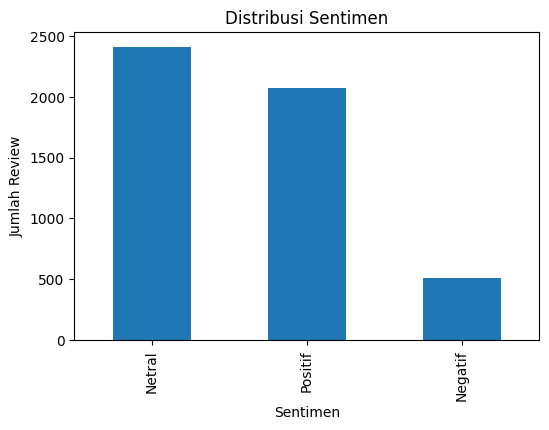


Pelabelan selesai.


In [6]:
# ==========================================================
# TAHAP 4 : PELABELAN SENTIMEN
# ==========================================================

print("="*60)
print("TAHAP 4 : PELABELAN SENTIMEN")
print("="*60)

kamus_positif = {
    "bagus","baik","mantap","keren","cepat","mudah",
    "praktis","lancar","aman","nyaman","membantu",
    "puas","memuaskan","hebat","terbaik","stabil",
    "responsif","lengkap","oke","top"
}

kamus_negatif = {
    "jelek","buruk","error","eror","bug","crash",
    "gagal","lemot","lambat","ganggu","login",
    "otp","blank","freeze","kecewa","parah",
    "susah","ribet","maintenance","hilang"
}


def label_sentimen(text):

    positif = 0
    negatif = 0

    for kata in text.split():

        if kata in kamus_positif:
            positif += 1

        if kata in kamus_negatif:
            negatif += 1

    if positif > negatif:
        return "Positif"

    elif negatif > positif:
        return "Negatif"

    else:
        return "Netral"


df["sentimen"] = df["stemming"].apply(label_sentimen)

print("\nDistribusi Sentimen")

display(df["sentimen"].value_counts())

plt.figure(figsize=(6,4))

df["sentimen"].value_counts().plot(
    kind="bar"
)

plt.title("Distribusi Sentimen")

plt.xlabel("Sentimen")

plt.ylabel("Jumlah Review")

plt.show()

df.to_csv(
    "wondrbyBNI_sentimen.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nPelabelan selesai.")

Data LSTM

In [4]:
# ==========================================================
# TAHAP 5 : PERSIAPAN DATA LSTM
# ==========================================================

print("="*60)
print("TAHAP 5 : PERSIAPAN DATA LSTM")
print("="*60)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
import pandas as pd # Import pandas

# Load the processed dataframe
df = pd.read_csv('wondrbyBNI_sentimen.csv')

# ==========================================================
# FITUR DAN LABEL
# ==========================================================

X = df["stemming"].fillna("").astype(str)

y = df["sentimen"]

# ==========================================================
# ENCODING LABEL
# ==========================================================

encoder = LabelEncoder()

y = encoder.fit_transform(y)

print("\nMapping Label")

for kelas, angka in zip(
    encoder.classes_,
    encoder.transform(encoder.classes_)
):
    print(f"{kelas} --> {angka}")

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nJumlah Data")

print("Data Latih :", len(X_train))
print("Data Uji   :", len(X_test))

# ==========================================================
# TOKENIZER
# ==========================================================

VOCAB_SIZE = 10000

MAX_LENGTH = 100

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

X_train = tokenizer.texts_to_sequences(X_train)

X_test = tokenizer.texts_to_sequences(X_test)

# ==========================================================
# PADDING
# ==========================================================

X_train = pad_sequences(
    X_train,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    X_test,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

# ==========================================================
# ONE HOT ENCODING
# ==========================================================

y_train = to_categorical(y_train)

y_test = to_categorical(y_test)

print("\nShape Data")

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

print("\nPersiapan data selesai.")

TAHAP 5 : PERSIAPAN DATA LSTM

Mapping Label
Negatif --> 0
Netral --> 1
Positif --> 2

Jumlah Data
Data Latih : 4000
Data Uji   : 1000

Shape Data
X_train : (4000, 100)
X_test  : (1000, 100)
y_train : (4000, 3)
y_test  : (1000, 3)

Persiapan data selesai.


Pemodelan Algoritma LSTM

In [20]:
import tensorflow as tf

tf.keras.backend.clear_session() # Clear any old TensorFlow session state

# ==========================================================
# TAHAP 6 : PEMBANGUNAN MODEL LSTM
# ==========================================================

print("="*60)
print("TAHAP 6 : PEMBANGUNAN MODEL LSTM")
print("="*60)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# Define VOCAB_SIZE and MAX_LENGTH from the data preparation step
VOCAB_SIZE = 10000
MAX_LENGTH = 100

# ==========================================================
# CALLBACK
# ==========================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "model_lstm.keras",
    monitor="val_accuracy",
    save_best_only=True
)

# ==========================================================
# MODEL
# ==========================================================

model = Sequential()

model.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128
        # Removed deprecated input_length argument
    )
)

model.add(
    Bidirectional(
        LSTM(
            128,
            return_sequences=True
        )
    )
)

model.add(
    Dropout(0.3)
)

model.add(
    Bidirectional(
        LSTM(64)
    )
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        64,
        activation="relu"
    )
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        3,
        activation="softmax"
    )
)

# Explicitly build the model before summary and training
model.build(input_shape=(None, MAX_LENGTH))

# ==========================================================
# COMPILE
# ==========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

TAHAP 6 : PEMBANGUNAN MODEL LSTM


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,715,971 (6.55 MB)

 Trainable params: 1,715,971 (6.55 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# ==========================================================
# TAHAP 7 : TRAINING MODEL LSTM
# ==========================================================

print("="*60)
print("TAHAP 7 : TRAINING MODEL LSTM")
print("="*60)

import time

start_time_lstm = time.time()

history = model.fit(
    X_train,
    y_train, # Use y_train directly as it's already one-hot encoded
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test), # Use y_test directly as it's already one-hot encoded
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ],
    verbose=1
)

training_time_lstm = time.time() - start_time_lstm

print(f"\nTraining selesai dalam {training_time_lstm:.2f} detik")

TAHAP 7 : TRAINING MODEL LSTM
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 73s 523ms/step - accuracy: 0.7010 - loss: 0.6015 - val_accuracy: 0.9230 - val_loss: 0.1974 - learning_rate: 0.0010
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 77s 489ms/step - accuracy: 0.9513 - loss: 0.1355 - val_accuracy: 0.9610 - val_loss: 0.1295 - learning_rate: 0.0010
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 62s 496ms/step - accuracy: 0.9820 - loss: 0.0596 - val_accuracy: 0.9650 - val_loss: 0.1246 - learning_rate: 0.0010
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 60s 484ms/step - accuracy: 0.9895 - loss: 0.0370 - val_accuracy: 0.9620 - val_loss: 0.1303 - learning_rate: 0.0010
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.9920 - loss: 0.0277
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
125/125 ━━━━━━━━━━━━━━━━━━━━ 82s 483ms/step - accuracy: 0.9915 - loss: 0.0264 - val_accuracy: 0.9650 - val_loss: 0.1735 - learning_rate: 0.0010
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 60

In [12]:
# ==========================================================
# TAHAP 8 : EVALUASI MODEL LSTM
# ==========================================================

print("="*60)
print("TAHAP 8 : EVALUASI MODEL LSTM")
print("="*60)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import numpy as np
# from tensorflow.keras.utils import to_categorical # Removed, as y_test is already one-hot encoded

# y_test is already one-hot encoded from the data preparation step
# y_test_one_hot = to_categorical(y_test, num_classes=len(encoder.classes_))

# Evaluasi model
loss, acc = model.evaluate(
    X_test,
    y_test, # Use y_test directly as it's already one-hot encoded
    verbose=0
)

print(f"Loss     : {loss:.4f}")
print(f"Akurasi  : {acc*100:.2f}%")

# Prediksi
y_pred = model.predict(X_test, verbose=0)

y_pred_class = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1) # Use the one-hot encoded y_test for argmax

# Hitung metrik
accuracy_lstm = accuracy_score(y_true, y_pred_class)

precision_lstm = precision_score(
    y_true,
    y_pred_class,
    average="weighted"
)

recall_lstm = recall_score(
    y_true,
    y_pred_class,
    average="weighted"
)

f1_lstm = f1_score(
    y_true,
    y_pred_class,
    average="weighted"
)

print("\nClassification Report")
print(classification_report(
    y_true,
    y_pred_class,
    target_names=encoder.classes_
))

TAHAP 8 : EVALUASI MODEL LSTM
Loss     : 1.1046
Akurasi  : 35.40%

Classification Report
              precision    recall  f1-score   support

     Negatif       0.23      0.94      0.37       102
      Netral       0.00      0.00      0.00       483
     Positif       0.45      0.62      0.52       415

    accuracy                           0.35      1000
   macro avg       0.22      0.52      0.30      1000
weighted avg       0.21      0.35      0.25      1000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Data SVM

In [14]:
# ==========================================================
# TAHAP 5 : PERSIAPAN DATA SVM
# ==========================================================

print("="*60)
print("TAHAP 5 : PERSIAPAN DATA SVM")
print("="*60)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# ==========================================================
# FITUR DAN LABEL
# ==========================================================

X = df["stemming"].fillna("").astype(str)
y = df["sentimen"]

# ==========================================================
# ENCODING LABEL
# ==========================================================

encoder = LabelEncoder()
y = encoder.fit_transform(y)

print("\nMapping Label")

for kelas, angka in zip(encoder.classes_,
                         encoder.transform(encoder.classes_)):
    print(f"{kelas} --> {angka}")

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nJumlah Data")
print("Data Latih :", len(X_train))
print("Data Uji   :", len(X_test))

# ==========================================================
# TF-IDF
# ==========================================================

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_train = tfidf.fit_transform(X_train)
X_test = tfidf.transform(X_test)

print("\nShape Data")
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

TAHAP 5 : PERSIAPAN DATA SVM

Mapping Label
Negatif --> 0
Netral --> 1
Positif --> 2

Jumlah Data
Data Latih : 4000
Data Uji   : 1000

Shape Data
X_train : (4000, 10000)
X_test  : (1000, 10000)


In [15]:
# ==========================================================
# TAHAP 6 : PEMBANGUNAN MODEL SVM
# ==========================================================

print("="*60)
print("TAHAP 6 : PEMBANGUNAN MODEL SVM")
print("="*60)

from sklearn.svm import SVC

model_svm = SVC(
    kernel="linear",
    C=1,
    random_state=42
)

print("Model SVM berhasil dibuat.")

TAHAP 6 : PEMBANGUNAN MODEL SVM
Model SVM berhasil dibuat.


In [16]:
# ==========================================================
# TAHAP 7 : TRAINING MODEL
# ==========================================================

print("="*60)
print("TAHAP 7 : TRAINING MODEL")
print("="*60)

import time

start = time.time()

model_svm.fit(X_train, y_train)

training_time_svm = time.time() - start

print(f"Training selesai dalam {training_time_svm:.2f} detik")

TAHAP 7 : TRAINING MODEL
Training selesai dalam 0.65 detik


In [17]:
# ==========================================================
# TAHAP 8 : EVALUASI MODEL
# ==========================================================

print("="*60)
print("TAHAP 8 : EVALUASI MODEL")
print("="*60)

from sklearn.metrics import accuracy_score

y_pred = model_svm.predict(X_test)

accuracy_svm = accuracy_score(y_test, y_pred)

print(f"Akurasi : {accuracy_svm*100:.2f}%")

TAHAP 8 : EVALUASI MODEL
Akurasi : 97.60%


In [18]:
# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
))

              precision    recall  f1-score   support

     Negatif       0.96      0.86      0.91       102
      Netral       0.96      0.99      0.98       483
     Positif       1.00      0.99      0.99       415

    accuracy                           0.98      1000
   macro avg       0.97      0.95      0.96      1000
weighted avg       0.98      0.98      0.98      1000



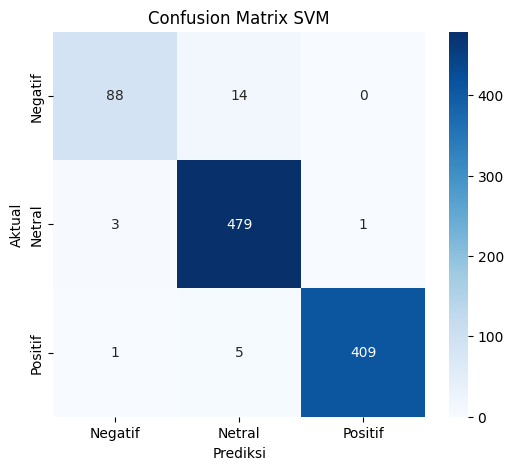

In [19]:
# ==========================================================
# CONFUSION MATRIX
# ==========================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix SVM")

plt.show()

In [21]:
# ==========================================================
# PERHITUNGAN METRIK
# ==========================================================

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

precision_svm = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall_svm = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1_svm = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

In [23]:
# ==========================================================
# TABEL HASIL EVALUASI
# ==========================================================

hasil_svm = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time (detik)"
    ],
    "Value":[
        accuracy_svm,
        precision_svm,
        recall_svm,
        f1_svm,
        training_time_svm
    ]
})

display(hasil_svm)

,Metric,Value
0,Accuracy,0.976000
1,Precision,0.976125
2,Recall,0.976000
3,F1 Score,0.975691
4,Training Time (detik),0.650471


In [24]:
# ==========================================================
# SIMPAN MODEL
# ==========================================================

import pickle

with open("model_svm.pkl", "wb") as file:
    pickle.dump(model_svm, file)

with open("tfidf.pkl", "wb") as file:
    pickle.dump(tfidf, file)

with open("label_encoder.pkl", "wb") as file:
    pickle.dump(encoder, file)

print("Model berhasil disimpan.")

Model berhasil disimpan.


In [25]:
# ==========================================================
# PREDIKSI REVIEW BARU
# ==========================================================

import re

def prediksi_sentimen_svm(review):

    review = review.lower()

    review = re.sub(r"http\S+", " ", review)
    review = re.sub(r"[^a-zA-Z\s]", " ", review)
    review = re.sub(r"\s+", " ", review).strip()

    review = tfidf.transform([review])

    prediksi = model_svm.predict(review)

    hasil = encoder.inverse_transform(prediksi)[0]

    print("="*60)
    print("Review")
    print(review)
    print("="*60)
    print("Sentimen :", hasil)

TAHAP 9 : PERBANDINGAN ALGORITMA LSTM DAN SVM

Tabel Perbandingan Algoritma


,Metrik,LSTM,SVM
0,Accuracy,0.354000,0.976000
1,Precision,0.208712,0.976125
2,Recall,0.354000,0.976000
3,F1-Score,0.253170,0.975691


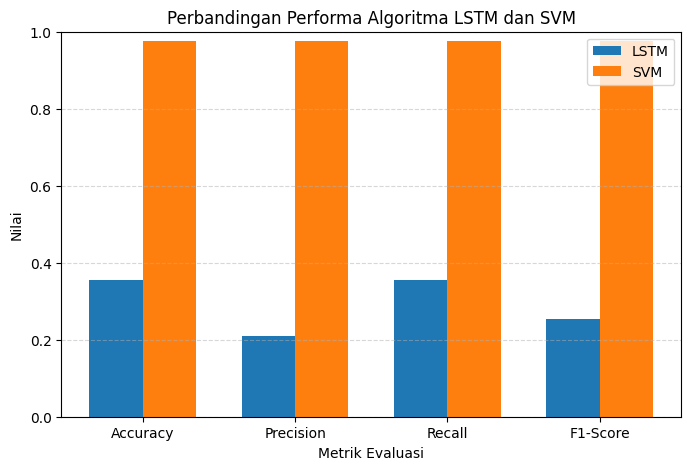

KESIMPULAN PERBANDINGAN
Model Terbaik : SVM

Accuracy  SVM  : 97.60%
Accuracy  LSTM : 35.40%
Precision SVM  : 97.61%
Precision LSTM : 20.87%
Recall    SVM  : 97.60%
Recall    LSTM : 35.40%
F1-Score  SVM  : 97.57%
F1-Score  LSTM : 25.32%

Kesimpulan :
Berdasarkan hasil evaluasi, algoritma SVM memiliki
performa yang lebih baik dibandingkan algoritma LSTM.
Oleh karena itu, model SVM dipilih sebagai model
terbaik untuk analisis sentimen ulasan aplikasi
Wondr by BNI.


In [29]:
# ==========================================================
# TAHAP 9 : PERBANDINGAN ALGORITMA LSTM DAN SVM
# ==========================================================

print("="*60)
print("TAHAP 9 : PERBANDINGAN ALGORITMA LSTM DAN SVM")
print("="*60)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# TABEL PERBANDINGAN
# ==========================================================

perbandingan = pd.DataFrame({
    "Metrik": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "LSTM": [
        accuracy_lstm,
        precision_lstm,
        recall_lstm,
        f1_lstm
    ],
    "SVM": [
        accuracy_svm,
        precision_svm,
        recall_svm,
        f1_svm
    ]
})

print("\nTabel Perbandingan Algoritma")
display(perbandingan)

# ==========================================================
# GRAFIK PERBANDINGAN
# ==========================================================

plt.figure(figsize=(8,5))

x = np.arange(len(perbandingan))
width = 0.35

plt.bar(
    x - width/2,
    perbandingan["LSTM"],
    width,
    label="LSTM"
)

plt.bar(
    x + width/2,
    perbandingan["SVM"],
    width,
    label="SVM"
)

plt.xticks(x, perbandingan["Metrik"])
plt.ylim(0,1)
plt.ylabel("Nilai")
plt.xlabel("Metrik Evaluasi")
plt.title("Perbandingan Performa Algoritma LSTM dan SVM")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

# ==========================================================
# MENENTUKAN MODEL TERBAIK
# ==========================================================

print("="*60)
print("KESIMPULAN PERBANDINGAN")
print("="*60)

if accuracy_lstm > accuracy_svm:

    print("Model Terbaik : LSTM\n")

    print(f"Accuracy  LSTM : {accuracy_lstm*100:.2f}%")
    print(f"Accuracy  SVM  : {accuracy_svm*100:.2f}%")

    print(f"Precision LSTM : {precision_lstm*100:.2f}%")
    print(f"Precision SVM  : {precision_svm*100:.2f}%")

    print(f"Recall    LSTM : {recall_lstm*100:.2f}%")
    print(f"Recall    SVM  : {recall_svm*100:.2f}%")

    print(f"F1-Score  LSTM : {f1_lstm*100:.2f}%")
    print(f"F1-Score  SVM  : {f1_svm*100:.2f}%")

    print("\nKesimpulan :")
    print("Berdasarkan hasil evaluasi, algoritma LSTM memiliki")
    print("performa yang lebih baik dibandingkan algoritma SVM.")
    print("Hal ini ditunjukkan oleh nilai Accuracy, Precision,")
    print("Recall, dan F1-Score yang lebih tinggi.")
    print("Oleh karena itu, model LSTM dipilih sebagai model")
    print("terbaik untuk analisis sentimen ulasan aplikasi")
    print("Wondr by BNI.")

else:

    print("Model Terbaik : SVM\n")

    print(f"Accuracy  SVM  : {accuracy_svm*100:.2f}%")
    print(f"Accuracy  LSTM : {accuracy_lstm*100:.2f}%")

    print(f"Precision SVM  : {precision_svm*100:.2f}%")
    print(f"Precision LSTM : {precision_lstm*100:.2f}%")

    print(f"Recall    SVM  : {recall_svm*100:.2f}%")
    print(f"Recall    LSTM : {recall_lstm*100:.2f}%")

    print(f"F1-Score  SVM  : {f1_svm*100:.2f}%")
    print(f"F1-Score  LSTM : {f1_lstm*100:.2f}%")

    print("\nKesimpulan :")
    print("Berdasarkan hasil evaluasi, algoritma SVM memiliki")
    print("performa yang lebih baik dibandingkan algoritma LSTM.")
    print("Oleh karena itu, model SVM dipilih sebagai model")
    print("terbaik untuk analisis sentimen ulasan aplikasi")
    print("Wondr by BNI.")

print("="*60)

In [28]:
from google.colab import files

files.download("model_svm.pkl")
files.download("tfidf.pkl")
files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>